In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from concept_abstraction.plotting import *
from concept_abstraction.utils import *

In [3]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [4]:
style_size = 'paper'

## Basic Experiments

In [6]:
training_times = {
    'cyclic_4':2500,
    'cyclic_16':2500,
    'tree_7': 2500, 
    'tree_31': 50000,
    'cart_pole': 250000,
    'mini_grid': 12_000_000,
    'pong': 12_000_000,
    'boxing': 12_000_000,
    'mimic': 250000,
}

In [7]:
number_concepts = [2,4,6,8,20,25,50]
environments = ["cyclic_4","cyclic_16","tree_7","tree_31","cart_pole","mini_grid","pong","boxing","mimic"]

random_results = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
random_selection = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
greedy_selection = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
greedy_iterative_selection = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
lp_selection = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]

for i,n in enumerate(number_concepts):
    for j,e in enumerate(environments):
        # TODO: Remove this, once we run more experiments
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'num_concepts_selected': n, 'training_timesteps': training_times[e], 'concept_source': 'human_selected_binary', 'run_two_stage': False})
        if len(matching_params) == 0 or 'basic_comparison' not in matching_params[0]:
            res = [0,0,0,0,0]
        else:
            print(n,e)
            basic_comparison = matching_params[0]['basic_comparison']
            res = [
                basic_comparison['random']['reward'],
                basic_comparison['random_selection']['reward'],
                basic_comparison['greedy']['reward'],
                basic_comparison['greedy_iterative']['reward'],
                basic_comparison['lp']['reward'],
            ]
        random_results[j][i] = res[0]
        random_selection[j][i] = res[1]
        greedy_selection[j][i] = res[2]
        greedy_iterative_selection[j][i] = res[3]
        lp_selection[j][i] = res[4]

        

2 tree_31
4 cyclic_4
4 cyclic_16
4 tree_7
4 tree_31
8 cart_pole
20 mini_grid
20 pong
25 boxing
50 mimic


/tmp/ipykernel_3183761/2190486366.py:26: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1


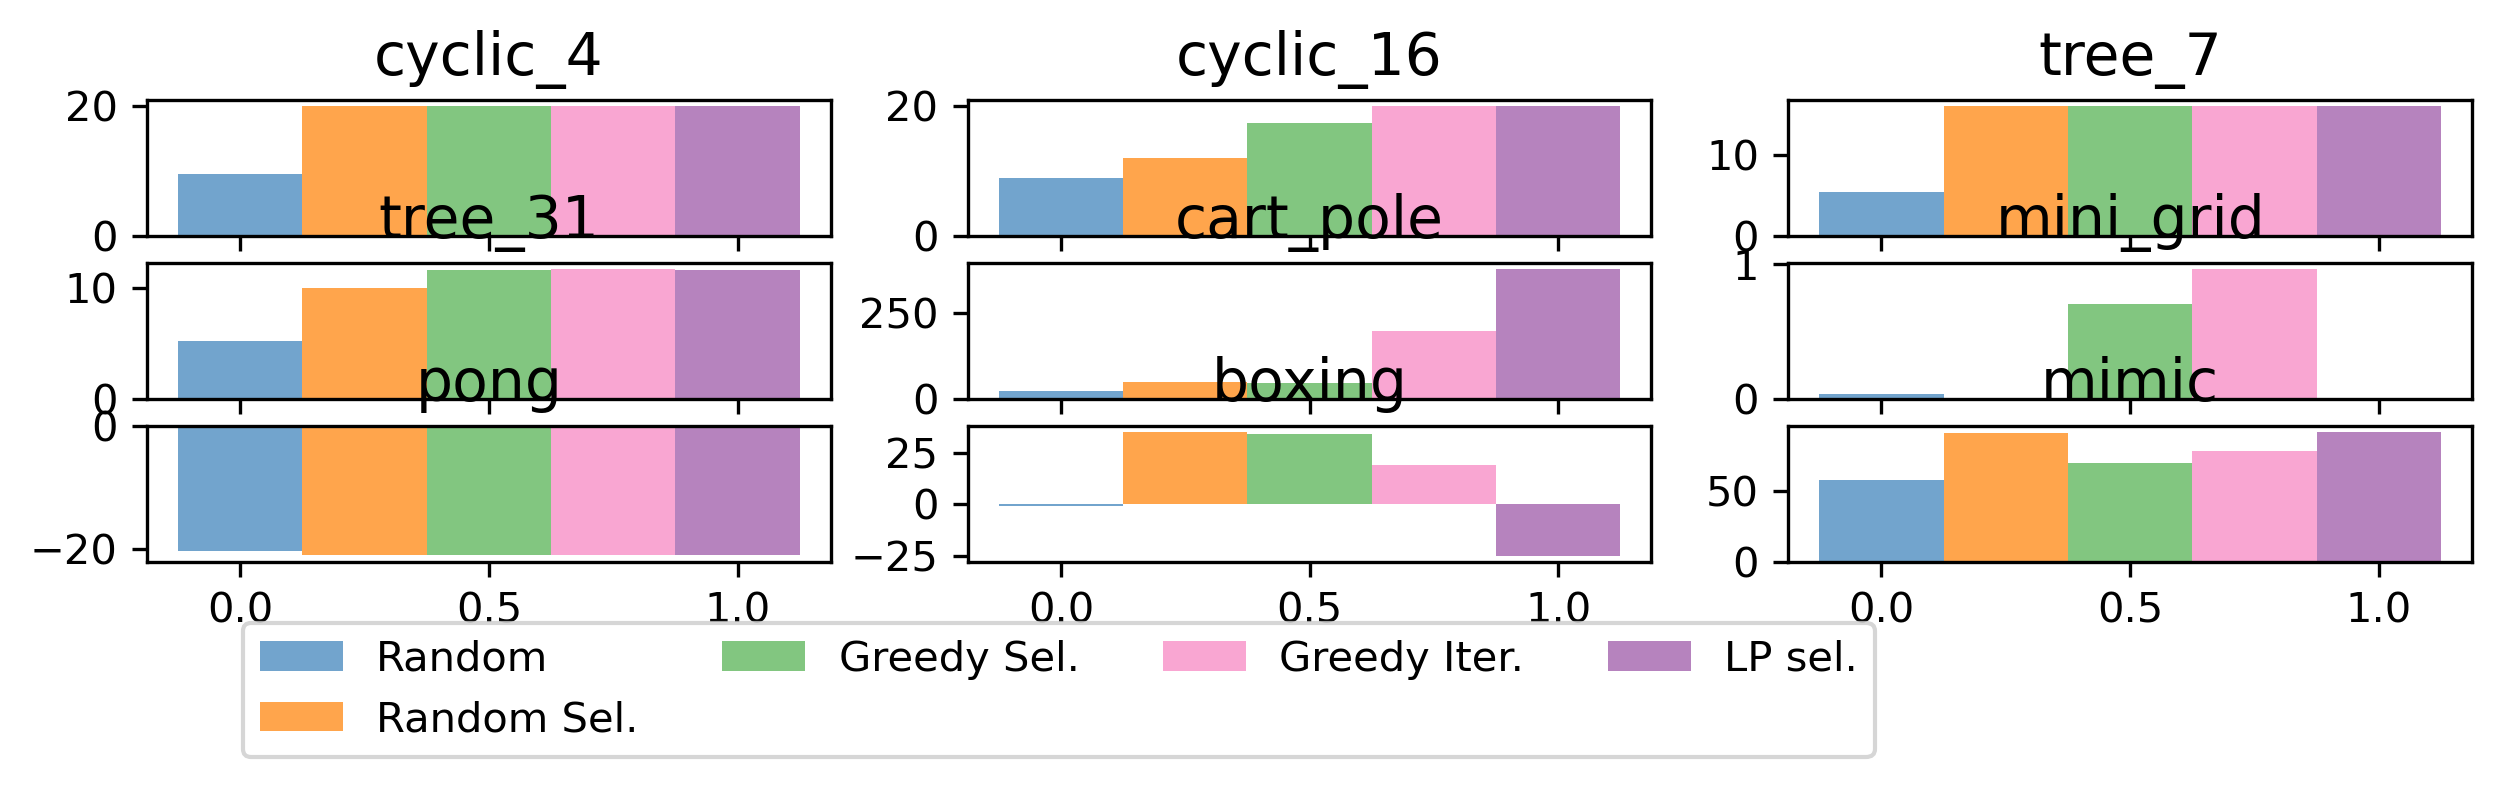

In [8]:
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size}
plt.tight_layout()

num_by_env = {
    "cyclic_4": 4, 
    "cyclic_16": 4,
    "tree_7": 4, 
    "tree_31": 2, 
    "cart_pole": 8, 
    "mini_grid": 20,
    "pong": 20,
    "boxing": 25,
    "mimic": 50,
}

for i in range(len(environments)):
    x_groups = list(range(5))
    idx = number_concepts.index(num_by_env[environments[i]])
    y_vals = [random_results[i][idx],random_selection[i][idx],
                greedy_selection[i][idx],greedy_iterative_selection[i][idx],
                lp_selection[i][idx]]
    x,y = index_to_tuple(i)

    d = {
        0: 'Random',
        1: 'Random Sel.',
        2: 'Greedy Sel.',
        3: 'Greedy Iter.',
        4: 'LP sel.'
    }

    plot_bar(ax[x][y],x_groups,y_vals,[0 for i in range(len(y_vals))], d,bar_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods.pdf",dpi=300, bbox_inches='tight')

/tmp/ipykernel_2637711/3278518898.py:27: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


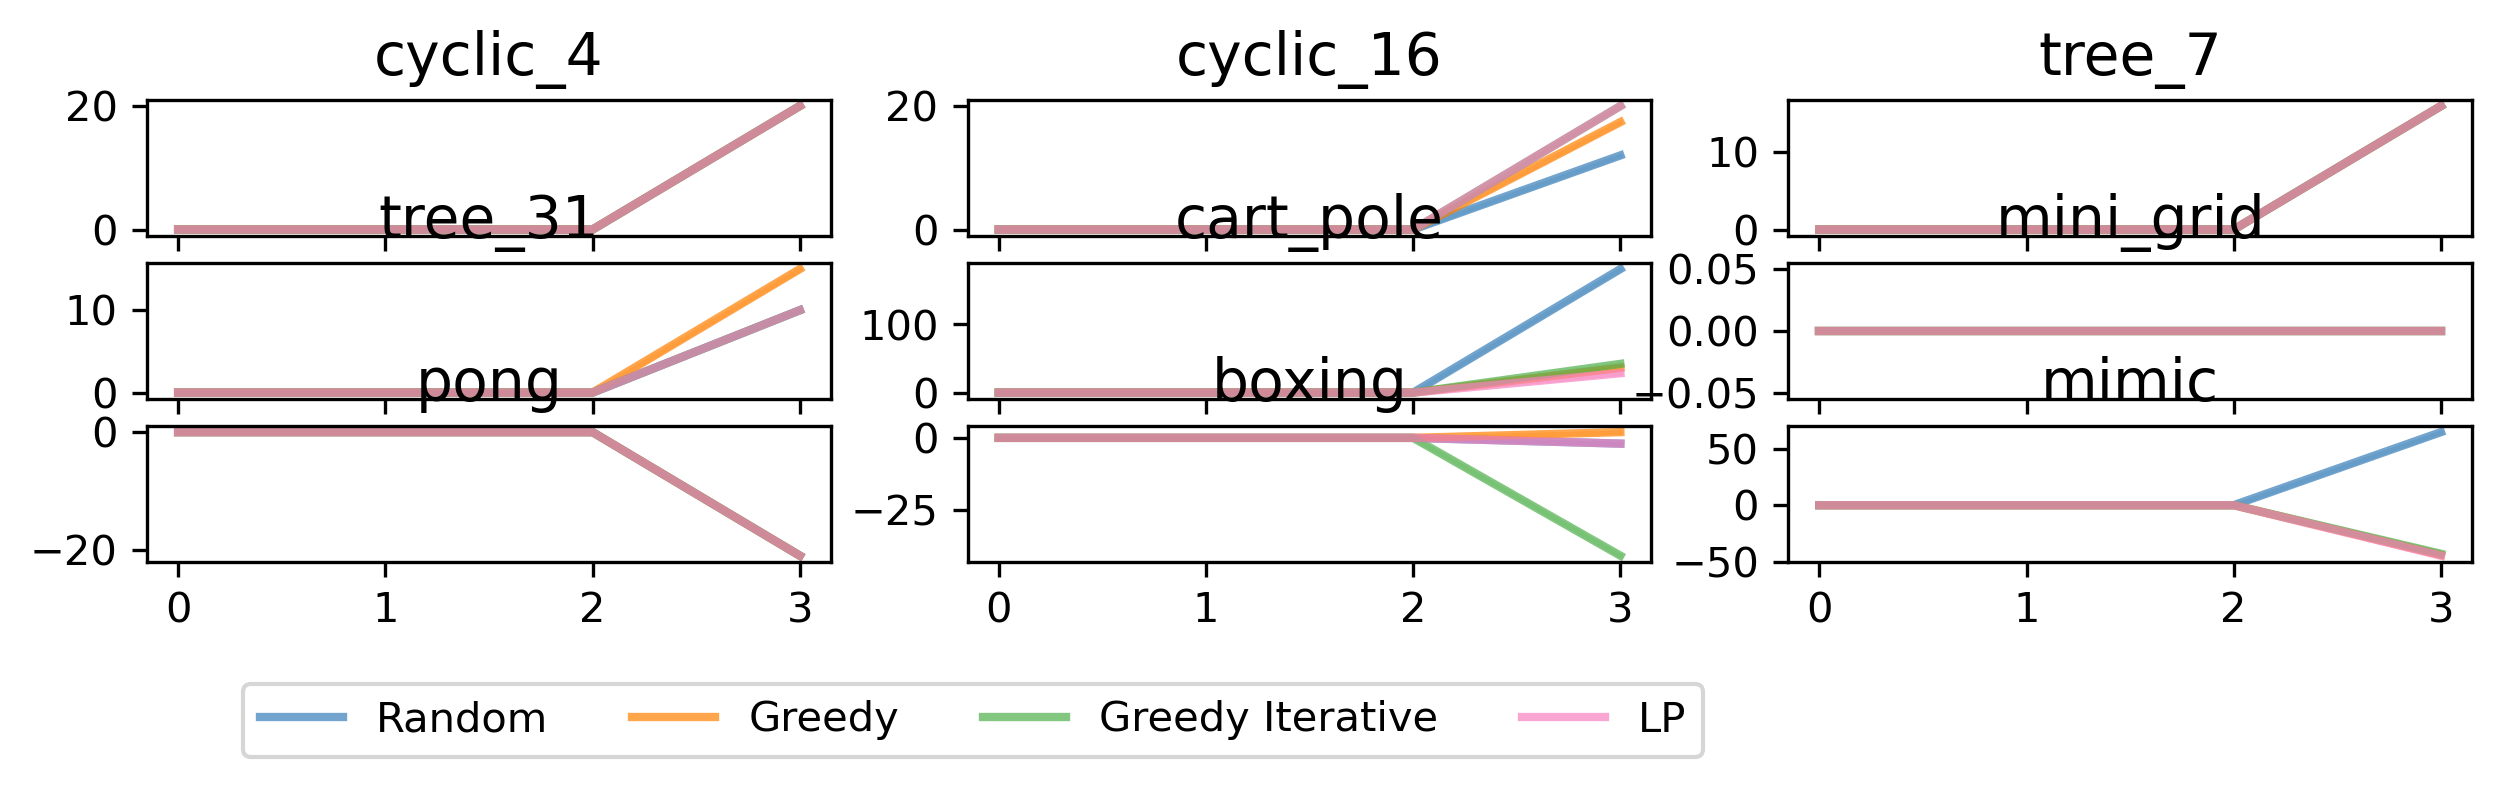

In [8]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Random","Greedy","Greedy Iterative","LP"]

for i in range(len(environments)):
    x_groups = [list(range(len(arr[0]))) for arr in [random_selection,greedy_selection,greedy_iterative_selection,lp_selection]]
    x_vals = number_concepts
    y_vals = [[arr[i][j] for j in range(len(arr[i]))] for arr in [random_selection,greedy_selection,greedy_iterative_selection,lp_selection]]
    x,y = index_to_tuple(i)

    plot_line(ax[x][y],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/number_of_concepts_basic.pdf",dpi=300, bbox_inches='tight')

In [23]:
number_concepts = [1,2,3,4]
environments = ["cart_pole","pong","boxing"]

random_results = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
random_selection = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
greedy_selection = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
greedy_iterative_selection = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]
lp_selection = [[0 for i in range(len(number_concepts))] for i in range(len(environments))]

for i,n in enumerate(number_concepts):
    for j,e in enumerate(environments):
        # TODO: Remove this, once we run more experiments
        if n <= 3:
            res = [0,0,0,0,0]
        else:
            matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'num_concepts_selected': n, 'training_timesteps': training_times[e], 'concept_source': 'human_selected', 'run_two_stage': False})
            basic_comparison = matching_params[0]['basic_comparison']
            res = [
                basic_comparison['random']['reward'],
                basic_comparison['random_selection']['reward'],
                basic_comparison['greedy']['reward'],
                basic_comparison['greedy_iterative']['reward'],
                basic_comparison['lp']['reward'],
            ]
        random_results[j][i] = res[0]
        random_selection[j][i] = res[1]
        greedy_selection[j][i] = res[2]
        greedy_iterative_selection[j][i] = res[3]
        lp_selection[j][i] = res[4]

        

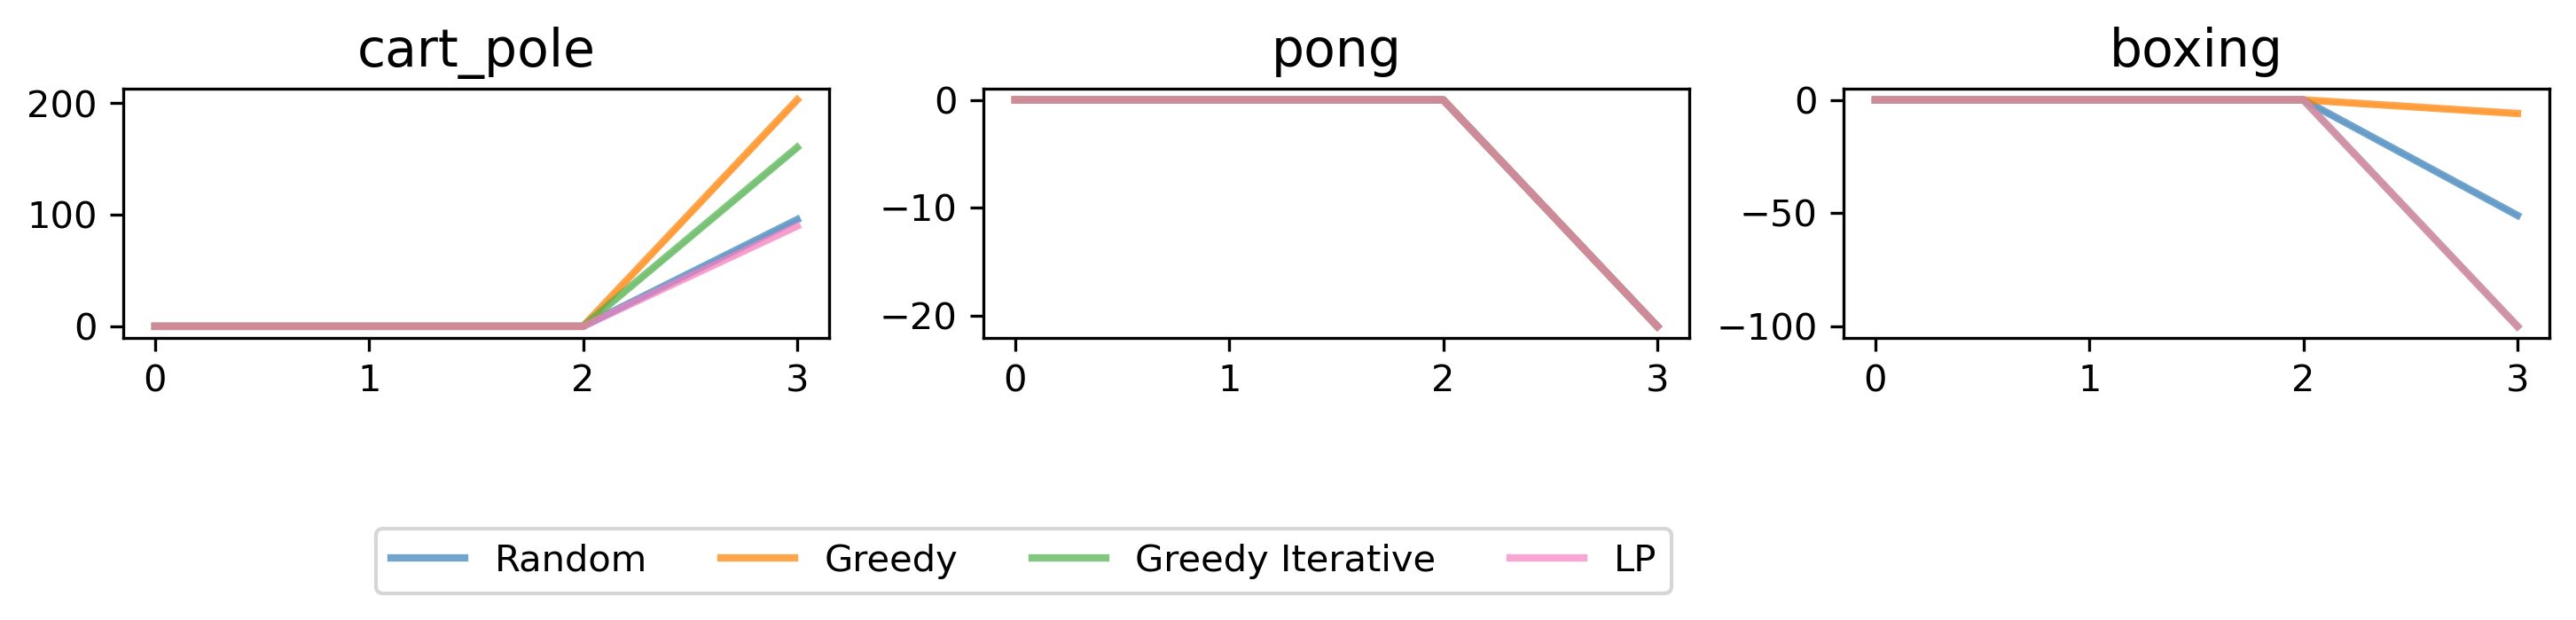

In [24]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Random","Greedy","Greedy Iterative","LP"]

for i in range(len(environments)):
    x_groups = [list(range(len(arr[0]))) for arr in [random_selection,greedy_selection,greedy_iterative_selection,lp_selection]]
    x_vals = number_concepts
    y_vals = [[arr[i][j] for j in range(len(arr[i]))] for arr in [random_selection,greedy_selection,greedy_iterative_selection,lp_selection]]
    x,y = index_to_tuple(i)

    plot_line(ax[x][y],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/number_of_concepts_continuous.pdf",dpi=300, bbox_inches='tight')

In [11]:
# Investigating Selected Pong Concepts

n = 4
e = "pong"
concept_names = ["pong_paddle_y","pong_ball_x","pong_ball_y","pong_ball_v_x","pong_ball_v_y","pong_enemy_y","pong_enemy_v_y"]
binary_concept_names = []
for i in concept_names:
    binary_concept_names.append(i+"<0")
    binary_concept_names.append(i+">=0")
matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'num_concepts_selected': n, 'training_timesteps': training_times[e], 'concept_source': 'human_selected_binary', 'run_two_stage': False})

for key in ['greedy','greedy_iterative','lp']:
    selected_concepts = matching_params[0]['basic_comparison'][key]['concepts']
    selected_concepts = [binary_concept_names[i] for i in selected_concepts]
    print(key,selected_concepts)

greedy ['pong_paddle_y<0', 'pong_paddle_y>=0', 'pong_ball_x<0', 'pong_ball_x>=0']
greedy_iterative ['pong_paddle_y<0', 'pong_ball_x<0', 'pong_ball_v_x<0', 'pong_ball_v_y<0']
lp ['pong_paddle_y<0', 'pong_ball_x<0', 'pong_ball_v_x>=0']


## Imperfect Concepts

In [12]:
fixed_accuracies = [0.25,0.5,0.75]
num_concepts = [3,15,4,6,8,89,14,16,82]
environments = ["cyclic_4","cyclic_16","tree_7","tree_31","cart_pole","mini_grid","pong","boxing","mimic"]

greedy_selection = [[0 for i in range(len(fixed_accuracies))] for i in range(len(environments))]
greedy_iterative_selection = [[0 for i in range(len(fixed_accuracies))] for i in range(len(environments))]
lp_selection = [[0 for i in range(len(fixed_accuracies))] for i in range(len(environments))]
imperfect_selection = [[0 for i in range(len(fixed_accuracies))] for i in range(len(environments))]

for i,n in enumerate(fixed_accuracies):
    for j,e in enumerate(environments):
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e,'num_concepts_selected': 4, 
                        'training_timesteps': training_times[e], 'concept_source': 'human_selected_binary', 'run_two_stage': False,
                        'cbm_accuracy_by_concept': [n for i in range(num_concepts[j])]})
        if len(matching_params) > 0 and 'inaccurate_comparison' in matching_params[0]:
            imperfect_comparison = matching_params[0]['inaccurate_comparison']
            res = [
                imperfect_comparison['greedy']['binary']['reward'],
                imperfect_comparison['greedy_iterative']['binary']['reward'],
                imperfect_comparison['lp']['binary']['reward'],
                imperfect_comparison['imperfect_lp']['binary'],
            ]

        else:
            res = [0,0,0,0]

        greedy_selection[j][i] = res[0]
        greedy_iterative_selection[j][i] = res[1]
        lp_selection[j][i] = res[2]
        imperfect_selection[j][i] = res[3]

        

/tmp/ipykernel_2637711/303182474.py:27: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


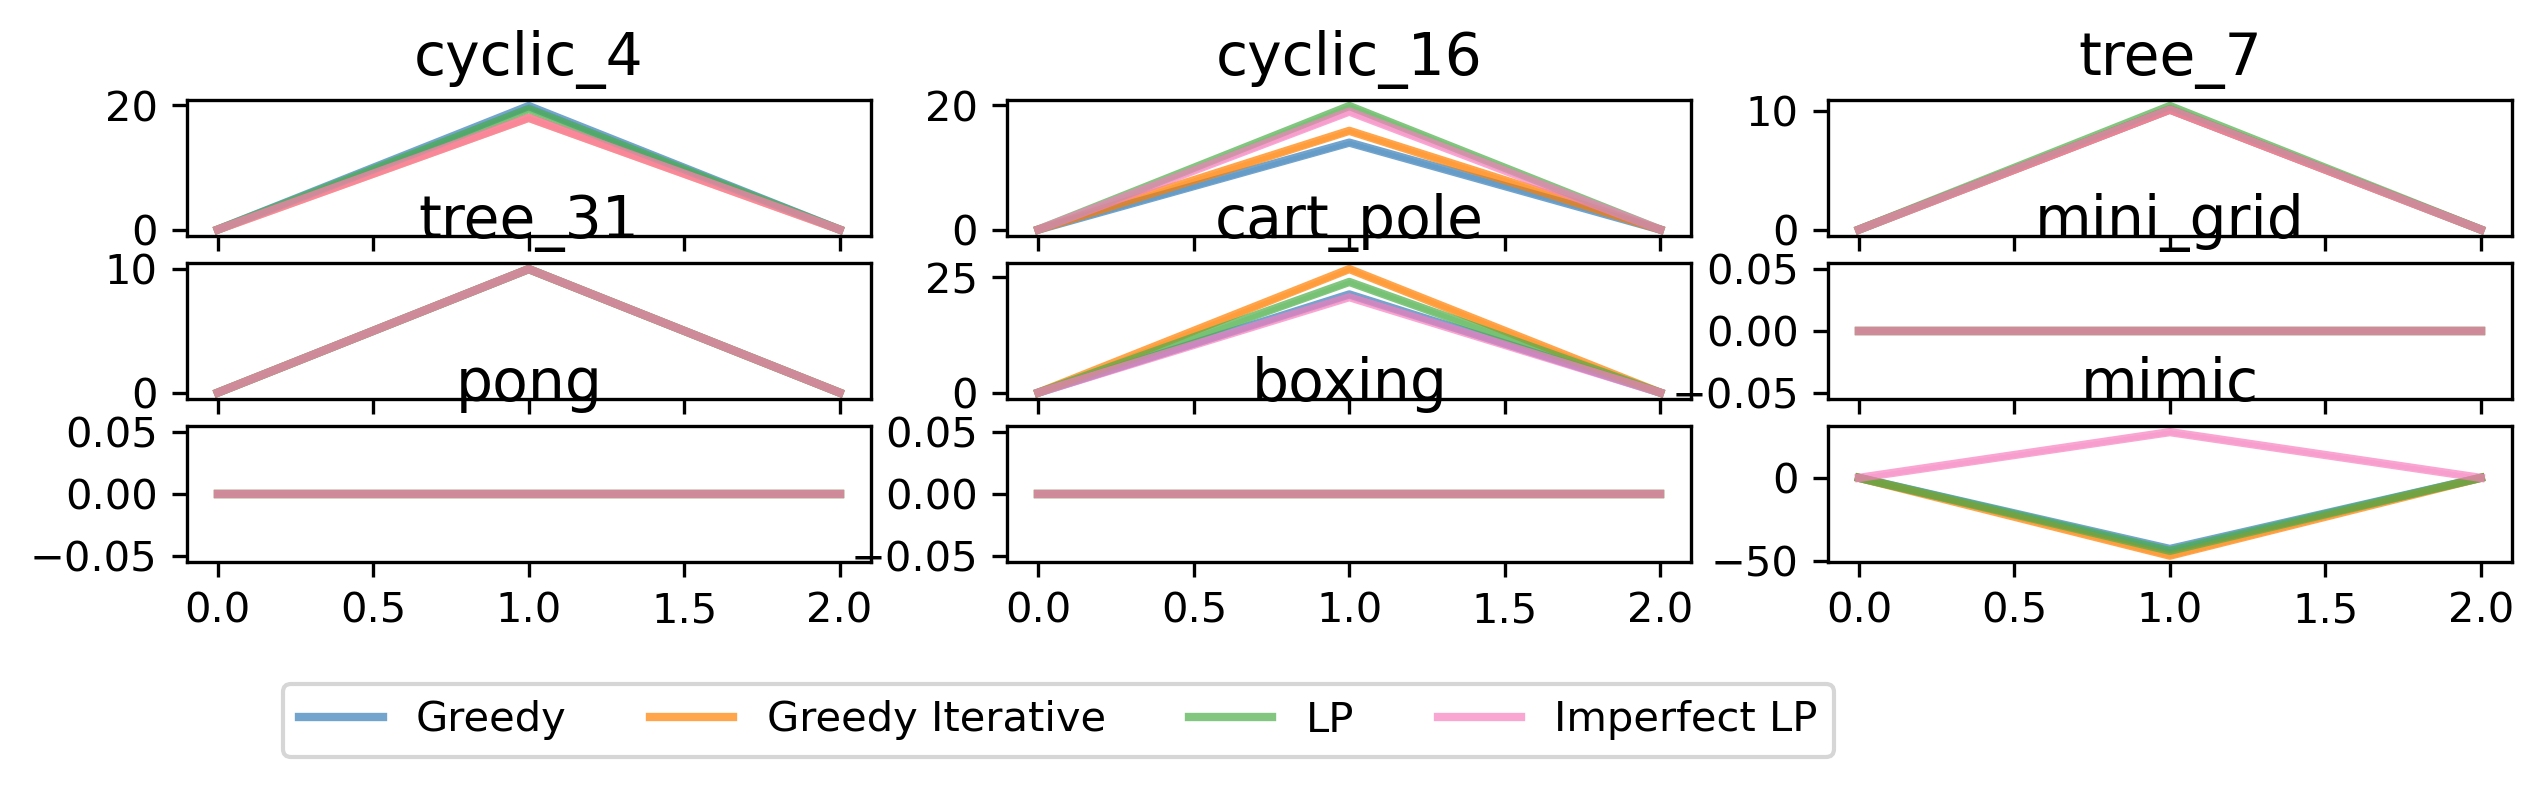

In [16]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (3,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Greedy","Greedy Iterative","LP","Imperfect LP"]

for i in range(len(environments)):
    x_groups = [list(range(len(arr[0]))) for arr in [greedy_selection,greedy_iterative_selection,lp_selection,imperfect_selection]]
    x_vals = fixed_accuracies
    y_vals = [[arr[i][j] for j in range(len(arr[i]))] for arr in [greedy_selection,greedy_iterative_selection,lp_selection,imperfect_selection]]
    x,y = index_to_tuple(i)

    plot_line(ax[x][y],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_comparison.pdf",dpi=300, bbox_inches='tight')

In [32]:
# TODO: With two-stage concepts, do we select the hgihest accuracy concepts, the most state abstract ones, or some mix

## Iterative Experiments

In [21]:
# Investigating Selected Pong Concepts
environments = ["cart_pole","pong","boxing"]
num_concepts_selected = 2
num_iterations = 2

perf_by_iteration = [[0 for i in range(num_iterations)] for j in environments]
bayesian_by_iteration = [[0 for i in range(num_iterations)] for j in environments]

for i,e in enumerate(environments):
    matching_params = get_results_matching_parameters("iterative","",{'environment_string': e,'num_concepts_selected': num_concepts_selected, 'training_timesteps': training_times[e], 'concept_source': 'human_selected_binary'})
    if len(matching_params) > 0:
        matching_params = matching_params[0]['iterative']
        perf_by_iteration[i] = [matching_params['iterative']['reward'] for i in range(num_iterations)]
        bayesian_by_iteration[i] = [matching_params['bayesian']['reward'] for i in range(num_iterations)]

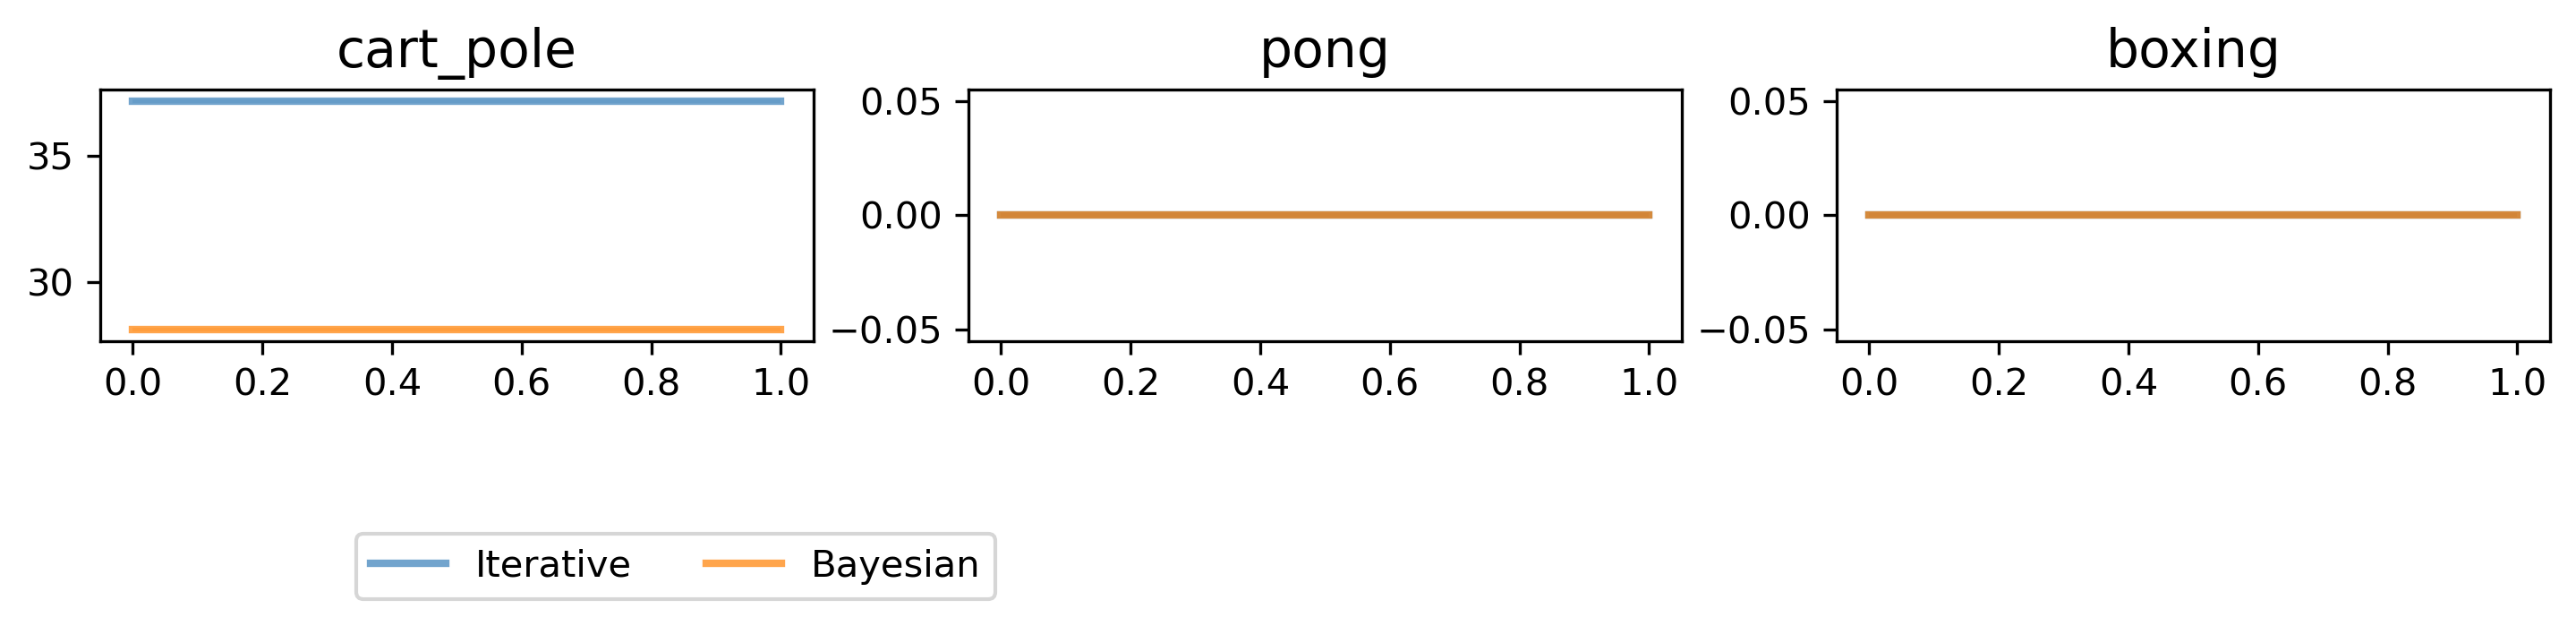

In [22]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,3)
def index_to_tuple(i):
    return (i//3,i%3)

def flatten_to_square(lst):
    res = [[0 for i in range(3)] for j in range(3)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = flatten_to_square(environments)

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Iterative","Bayesian"]

for i in range(len(environments)):
    x_groups = [list(range(len(arr[0]))) for arr in [perf_by_iteration,bayesian_by_iteration]]
    x_vals = list(range(1,num_iterations+1))
    y_vals = [[arr[i][j] for j in range(len(arr[i]))] for arr in [perf_by_iteration,bayesian_by_iteration]]
    x,y = index_to_tuple(i)

    plot_line(ax[x][y],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/iterative.pdf",dpi=300, bbox_inches='tight')

## CUB Experiments

In [7]:
num_concepts_selected = 112
matching_params = get_results_matching_parameters("cub","",{'num_concepts_selected': num_concepts_selected})
random_selection = matching_params[0]['random_selection']['values']
random_manual_selection = matching_params[0]['random_manual_selection']['values']
greedy_selection = matching_params[0]['greedy_selection']['values']
reference_concepts = matching_params[0]['manually_selected_concepts']
greedy_concepts = matching_params[0]['greedy_selection']['concepts']
greedy_manual_intersection = [len(set(i).intersection(set(reference_concepts)))/len(i) for i in greedy_concepts]

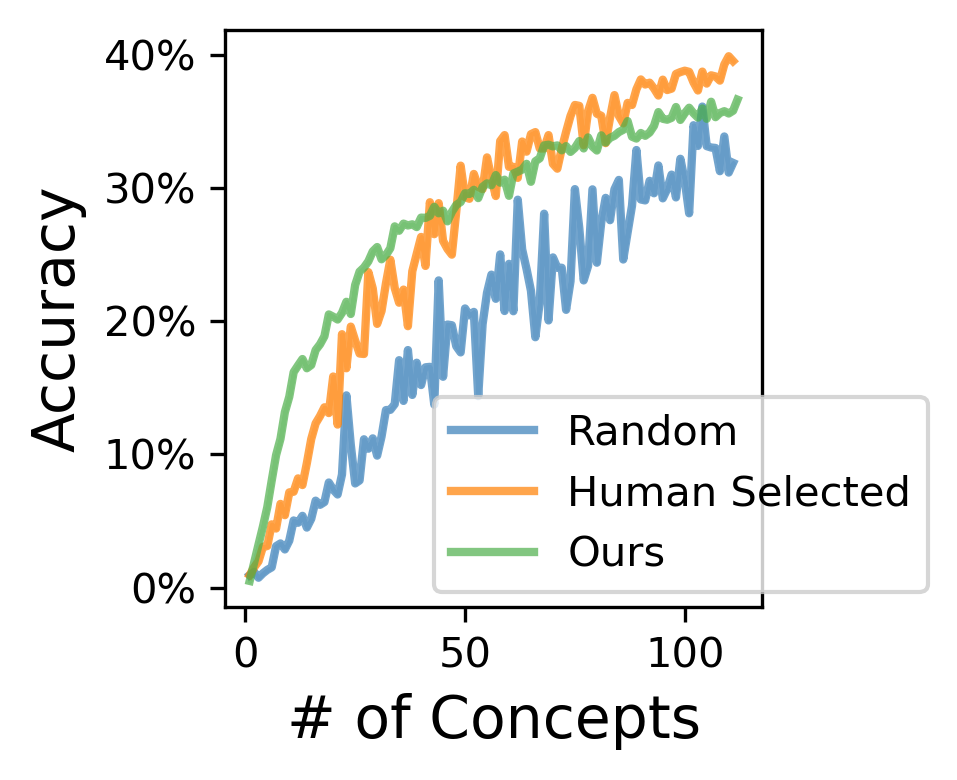

In [18]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)

sup_y_label = ""
overall_format = {'figsize':(3,3),
    'style_size': style_size,
    'has_grid': False, 
    'y_ticks': [[[[0,0.1,0.2,0.3,0.4],["0%","10%","20%","30%","40%"]]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=[["# of Concepts"]],y_labels=[["Accuracy"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Random","Human Selected","Ours"]

x_groups = [list(range(1,len(arr)+1)) for arr in [random_selection,random_manual_selection,greedy_selection]]
x_vals = list(range(1,num_concepts_selected+1))
y_vals = [[arr[j] for j in range(len(arr))] for arr in [random_selection,random_manual_selection,greedy_selection]]

plot_line(ax[0][0],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.35,-0.01),'fontsize': 10}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/cub.pdf",dpi=300, bbox_inches='tight')

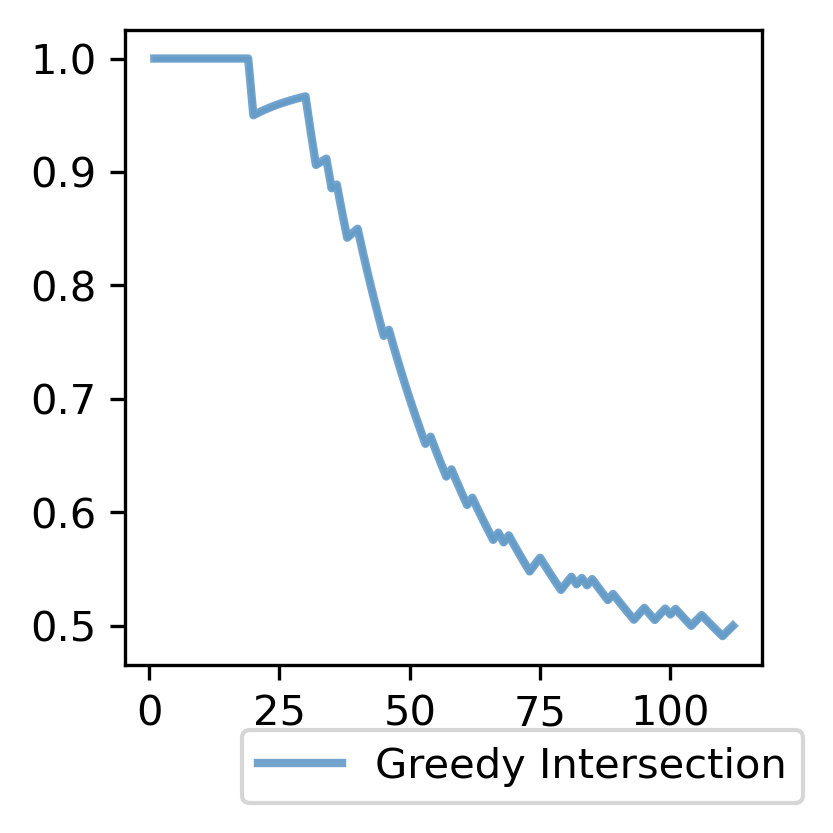

In [8]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)

sup_y_label = ""
overall_format = {'figsize':(3,3),
    'style_size': style_size,
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

all_labels = ["Greedy Intersection"]

x_groups = [list(range(1,len(arr)+1)) for arr in [greedy_manual_intersection]]
x_vals = list(range(1,num_concepts_selected+1))
y_vals = [[arr[j] for j in range(len(arr))] for arr in [greedy_manual_intersection]]

plot_line(ax[0][0],x_groups,y_vals,[[0 for i in range(len(arr))] for arr in y_vals],all_labels,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/cub_selected.pdf",dpi=300, bbox_inches='tight')

## Ablation Studies